# 9. Soft Kriging 


**Dataset:** Jura geochemical survey (`data/jura_data.csv`, 359 samples) + prediction grid (`data/jura_grid.csv`)

**Target:** Cadmium (Cd, mg/kg) exceedance of 1.0 mg/kg, informed by Zinc (Zn) as a cheap, densely-available proxy

**Library:** `pygstat.soft_kriging` — Markov-Bayes soft/indicator kriging (Zhu & Journel, 1993)


***
## Table of Contents

1. [Overview](#1-overview)
2. [Theory - Why Soft Data, and the Markov-Bayes Shortcut](#2-theory---why-soft-data-and-the-markov-bayes-shortcut)
3. [Theory - Calibration and the Combined Kriging System](#3-theory---calibration-and-the-combined-kriging-system)
4. [Python Setup](#4-python-setup)
5. [Load the Jura Data and Set Up the Scenario](#5-load-the-jura-data-and-set-up-the-scenario)
6. [Calibrate Soft Probabilities from Zn](#6-calibrate-soft-probabilities-from-zn)
7. [The Markov-Bayes Calibration Coefficient B](#7-the-markov-bayes-calibration-coefficient-b)
8. [Fit the Hard-Indicator Variogram](#8-fit-the-hard-indicator-variogram)
9. [Krige: Hard-Only vs. Markov-Bayes Soft Kriging](#9-krige-hard-only-vs-markov-bayes-soft-kriging)
10. [Validate on the Held-Out 80%](#10-validate-on-the-held-out-80)
11. [Map the Exceedance Probability Over Jura](#11-map-the-exceedance-probability-over-jura)
12. [Kriging Uncertainty](#12-kriging-uncertainty)
13. [CPU vs GPU Soft Kriging Timing](#13-cpu-vs-gpu-soft-kriging-timing)
14. [Summary and Conclusions](#14-summary-and-conclusions)
15. [Resources](#15-resources)


***
## 1. Overview

Every kriging method in earlier tutorials assumes a single, exact (**hard**)
measurement of the target variable at each sample location. In practice, exact
assays are often **expensive and sparse** (e.g. a certified laboratory Cd assay),
while a **cheap, dense, correlated proxy** is available almost everywhere (e.g. a
portable XRF reading, a geophysical survey, or — as here — a cheaper heavy-metal
assay measured at the same locations). **Soft kriging** fuses both: exact hard
data where you have them, and an uncertain but spatially dense *probability*
derived from the proxy everywhere else.

The classic algorithm is the **Markov-Bayes approach** of Zhu & Journel (1993):
rather than fitting a data-hungry hard–soft cross-variogram, it rescales the
*hard* indicator's own covariance model by a single calibration coefficient
$B$. **`pygstat.SoftKriging`** implements that combined ordinary-kriging system
in 2-D. This notebook tests it on a realistic scenario built from the Jura
geochemical survey: pretend only 20% of the 359 samples were ever sent for an
expensive Cd assay, but the cheaper Zn assay is available at all 359 locations.
The remaining 80% of Cd assays are held out for validation (the same split as
`tests/test_soft_kriging_jura.py`).

| Step | What we do |
|---|---|
| Data | Load `jura_data.csv` (359 samples) and `jura_grid.csv` (prediction nodes); threshold Cd at 1.0 mg/kg |
| Scenario | Stratified 20% / 80% split: 71 hard Cd assays, 288 held-out for scoring |
| Soft probabilities | Logistic $P(\mathrm{Cd} \ge 1 \mid \mathrm{Zn})$ fit on the hard subset only |
| Calibration | Estimate Markov-Bayes $B = \mathrm{Cov}(I,F)/\mathrm{Var}(F)$ from co-located pairs |
| Variogram | Exponential indicator model of the sparse hard Cd exceedance |
| Comparison | Hard-only IK vs. Zn-only logistic vs. Markov-Bayes soft kriging |
| Mapping | $P(\mathrm{Cd} \ge 1)$ and kriging variance on `jura_grid.csv` |
| CPU / GPU | Time k-NN `SoftKriging` on CPU vs GPU using **sgsim** Jura-like Cd + Zn ($n=8{,}000$) |

By the end you will have a calibrated soft-probability model, a $B$ coefficient,
held-out AUC / Brier scores showing that Zn-informed soft kriging beats sparse
hard-only indicator kriging, probability maps of Cd exceedance, and a CPU vs GPU
timing of the batched Markov–Bayes solve on an **SGS-simulated** Jura-like field
with $n > 5{,}000$.


***
## 2. Why Soft Data, and the Markov-Bayes Shortcut

For a threshold $z$, define the **hard indicator** at a hard-data location
$\mathbf{u}$,

$$
I(\mathbf{u}) =
\begin{cases}
1, & Z(\mathbf{u}) \ge z \\
0, & Z(\mathbf{u}) < z,
\end{cases}
$$

and a **soft probability** $F(\mathbf{u}) \in [0,1]$ at a soft-data location —
an estimate of $P[Z(\mathbf{u}) \ge z]$ derived from a correlated secondary
variable. A rigorous cokriging of $I$ and $F$ would need a hard–hard variogram
$\gamma_{II}(h)$, a soft–soft variogram $\gamma_{FF}(h)$, **and** a
cross-variogram $\gamma_{IF}(h)$. The last of these is notoriously hard to
estimate (it needs many co-located hard/soft pairs) and easy to get wrong: an
invalid cross-variogram breaks the whole cokriging system.

**Markov-Bayes avoids this entirely.** It assumes a Markov-type screening
property: conditional on the hard indicator at the same location, the soft data
everywhere else provide no *extra* information. Under that assumption, the
soft–soft and hard–soft covariances collapse to simple rescalings of the
**hard** covariance model $C_H(h)$ by one number, the calibration coefficient
$B$:

$$
C_{HH}(h) = C_H(h), \qquad
C_{HS}(h) = B \cdot C_H(h), \qquad
C_{SS}(h) = B^2 \cdot C_H(h).
$$

$B$ close to 1 means the soft data are almost as informative as hard data;
$B$ close to 0 means they carry essentially no information and should be
ignored. `SoftKriging` with $B = 0$ (or with no soft neighbours) therefore
degrades to ordinary indicator kriging — the method of Tutorial 07.

A small coding example with cutoff $z = 1.0$:

| Location | Cd (mg/kg) | $I(\mathrm{Cd} \ge 1)$ | Zn (mg/kg) | $F$ from logistic |
|---|---|---|---|---|
| A | 0.5 | 0 | 40 | low |
| B | 1.7 | 1 | 95 | high |
| C | 1.1 | 1 | 70 | moderate |

Hard data contribute the exact 0/1 values; soft data contribute $F$, down-weighted
by $B$.


***
## 3. Calibration and the Combined Kriging System

**Calibrating $B$.** From pairs where *both* the hard indicator and a soft
probability are known at (or near) the same location,

$$
B = \frac{\mathrm{Cov}(I, F)}{\mathrm{Var}(F)}.
$$

`pygstat.markov_bayes_calibrate` computes exactly this (matching each hard
datum to its nearest soft datum via a KD-tree, so hard and soft need not share
identical coordinates).

**Building the soft data.** When you only have a *continuous* proxy (like Zn),
not probabilities, `fit_soft_probability_model` calibrates
$P(I=1 \mid \text{proxy})$ with a **logistic regression** fit against
co-located hard indicator data.

**The combined ordinary kriging system.** With $n_H$ hard and $n_S$ soft
neighbours of a target $\mathbf{u}_0$, `SoftKriging` solves

$$
\begin{pmatrix}
C_{HH} & C_{HS} & \mathbf{1} \\
C_{HS}^\top & C_{SS} & \mathbf{1} \\
\mathbf{1}^\top & \mathbf{1}^\top & 0
\end{pmatrix}
\begin{pmatrix} \boldsymbol\lambda_H \\ \boldsymbol\lambda_S \\ \mu \end{pmatrix}
=
\begin{pmatrix} \mathbf{c}_{H0} \\ B\,\mathbf{c}_{S0} \\ 1 \end{pmatrix},
\qquad
\hat{P}(\mathbf{u}_0)
= \sum_i \lambda_{H,i}\, I(\mathbf{u}_i)
+ \sum_j \lambda_{S,j}\, F(\mathbf{u}_j).
$$

A single unbiasedness constraint covers **all** weights (hard and soft
together) — ordinary kriging, extended to two data types. After solving, the
estimate is clipped to $[0, 1]$. The kriging variance is the usual

$$
\sigma_K^2(\mathbf{u}_0)
= C_H(0) - \boldsymbol\lambda^\top \mathbf{c}_0 - \mu.
$$

**Search neighbourhood.** Distant samples should not inform a local
probability. The implementation builds a `cKDTree` on each data type and keeps
at most `max_neighbors_hard` / `max_neighbors_soft` points (optionally inside
`search_radius`). A small diagonal `regularization` keeps the soft–soft block
invertible when dense proxy locations sit close together. When `search_radius`
is `None` (k-NN), every prediction point has the same neighbourhood size, so
pygstat stacks the systems into one `(n_{\mathrm{pred}}, n_H+n_S+1, n_H+n_S+1)`
solve — NumPy on CPU, CuPy on GPU (`use_gpu`). A variable-radius search stays
on the per-point CPU loop. Section 13 times the k-NN path.


***
## 4. Python Setup

### 4.1 CPU and GPU

`SoftKriging` solves a **local** Markov–Bayes ordinary-kriging system at every prediction point. In the default **k-nearest-neighbor** mode (`search_radius=None`) every point has the same hard count $n_H$ and soft count $n_S$, so pygstat stacks the systems into one `(n_{\mathrm{pred}}, n_H+n_S+1, n_H+n_S+1)` batched `xp.linalg.solve` — NumPy on CPU, CuPy on GPU.

| Argument | What it controls |
|----------|------------------|
| `use_gpu` | Batched k-NN Markov–Bayes solve (NumPy or CuPy). |
| `search_radius` | If set, neighbor counts vary by point and the batch path is skipped (**CPU only**). |

`use_gpu` is:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` and stores the result in `USE_GPU`. `SoftKriging(...)` calls below pass `use_gpu=USE_GPU`. The Jura maps in §11 use k-NN (so they can run on GPU); **§13** times that path on an **SGS-simulated** Jura-like Cd/Zn field with $n > 5{,}000$.

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.


In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.modules.setdefault("tensorflow", None)
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.spatial.distance import pdist
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss

import pygstat
from pygstat import (
    SoftKriging,
    indicator_transform,
    markov_bayes_calibrate,
    fit_soft_probability_model,
    sgsim,
)
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

print("pygstat version:", pygstat.__version__)

# ── SoftKriging batched Markov–Bayes: CPU / GPU dispatch (CuPy) ───────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`).
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU (CuPy)      : {name}")
    except Exception:
        print("GPU (CuPy)      : available")
    print("Backend         : GPU (CuPy) — SoftKriging batched k-NN solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


pygstat version: 0.1.0
CuPy            : 14.2.0
GPU (CuPy)      : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — SoftKriging batched k-NN solve on GPU
use_gpu         : True


***
## 5. Load the Jura Data and Set Up the Scenario

The Jura data are 359 topsoil samples from the Swiss Jura, originally published
with Goovaerts (1997). Each location has **both** Cd and Zn measured — in
reality those assays are usually run together. Mapping uses the same
prediction lattice as Tutorial 04 (`data/jura_grid.csv`, ~6 000 nodes covering
the study area). To build a realistic soft-kriging scenario we pretend only a
random **20% (71 samples)** were ever sent for the expensive Cd assay — the
hard data — while Zn (the soft proxy) remains known everywhere, as it would be
if it came from a cheap portable sensor. The other **80% (288 samples)** are
held out entirely for validation: their true Cd exceedance is never shown to
the model.

The cutoff is **Cd $\ge$ 1.0 mg/kg**, the same contamination threshold used in
the ordinary-kriging tutorial. The split is stratified on the indicator and
uses `random_state=42`, matching `tests/test_soft_kriging_jura.py`.


In [2]:
jura = pd.read_csv("../data/jura_data.csv", index_col=0)
grid = pd.read_csv("../data/jura_grid.csv", index_col=0)
coords = jura[["Xloc", "Yloc"]].to_numpy(dtype=float)
coords_grid = grid[["Xloc", "Yloc"]].to_numpy(dtype=float)
cd = jura["Cd"].to_numpy(dtype=float)
zn = jura["Zn"].to_numpy(dtype=float)

THRESHOLD = 1.0
indicator_all = indicator_transform(cd, THRESHOLD, exceed=True)

print(f"Samples: {len(jura)}    Grid nodes: {len(grid)}")
print("Sample columns:", list(jura.columns))
print("Grid columns:  ", list(grid.columns))
print(f"\nCd >= {THRESHOLD} mg/kg exceedance rate = {indicator_all.mean():.1%}")
print(f"corr(Cd, Zn) = {jura['Cd'].corr(jura['Zn']):.3f}")
print("\nCadmium (mg/kg) summary:")
print(jura["Cd"].describe().round(3))
print("\nZinc (mg/kg) summary:")
print(jura["Zn"].describe().round(2))
jura.head()


Samples: 359    Grid nodes: 5957
Sample columns: ['Xloc', 'Yloc', 'Landuse', 'Rock', 'Cd', 'Co', 'Cr', 'Cu', 'Ni', 'Pb', 'Zn']
Grid columns:   ['Xloc', 'Yloc', 'Landuse', 'Rock']

Cd >= 1.0 mg/kg exceedance rate = 53.5%
corr(Cd, Zn) = 0.619

Cadmium (mg/kg) summary:
count    359.000
mean       1.288
std        0.859
min        0.135
25%        0.653
50%        1.100
75%        1.680
max        5.129
Name: Cd, dtype: float64

Zinc (mg/kg) summary:
count    359.00
mean      75.88
std       30.82
min       25.00
25%       54.60
50%       73.56
75%       90.00
max      259.84
Name: Zn, dtype: float64


,Xloc,Yloc,Landuse,Rock,Cd,Co,Cr,Cu,Ni,Pb,Zn
1,2.386,3.077,3,3,1.740,9.32,38.32,25.72,21.32,77.36,92.56
2,2.544,1.972,2,2,1.335,10.00,40.20,24.76,29.72,77.88,73.56
3,2.807,3.347,2,3,1.610,10.60,47.00,8.88,21.40,30.80,64.80
4,4.308,1.933,3,2,2.150,11.92,43.52,22.70,29.72,56.40,90.00
5,4.383,1.081,3,5,1.565,16.32,38.52,34.32,26.20,66.40,88.40


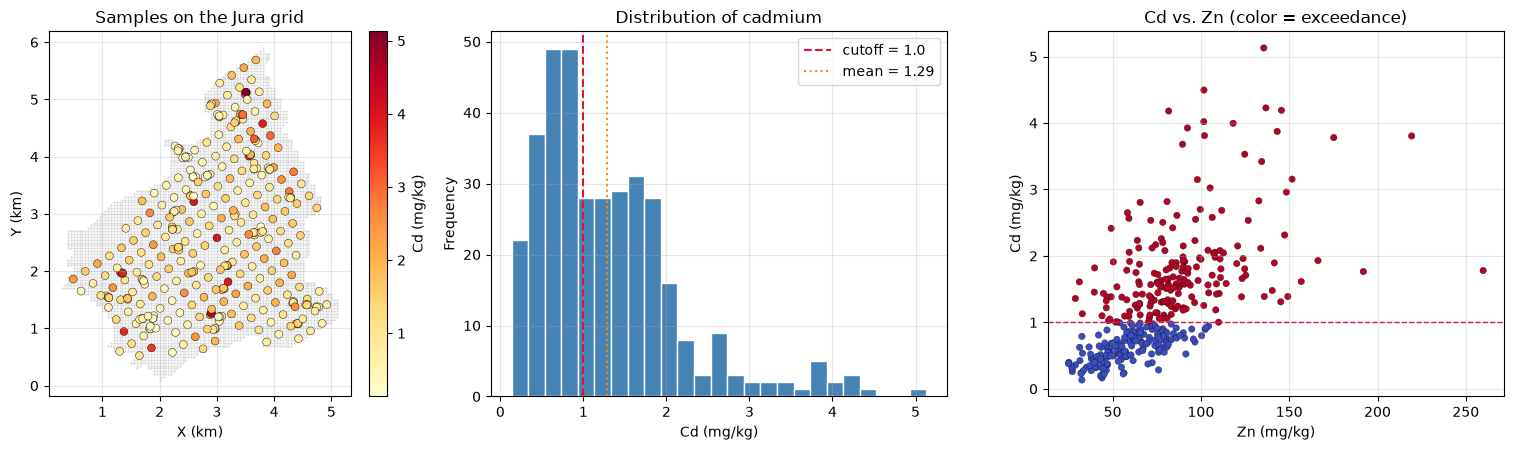

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

axes[0].scatter(grid["Xloc"], grid["Yloc"], s=2, c="0.85", marker=".")
sc = axes[0].scatter(
    jura["Xloc"], jura["Yloc"], c=cd, cmap="YlOrRd", s=32,
    edgecolors="k", linewidths=0.3,
)
plt.colorbar(sc, ax=axes[0], label="Cd (mg/kg)", fraction=0.046, pad=0.04)
axes[0].set_title("Samples on the Jura grid")
axes[0].set_xlabel("X (km)")
axes[0].set_ylabel("Y (km)")
axes[0].set_aspect("equal")

axes[1].hist(cd, bins=25, color="steelblue", edgecolor="white")
axes[1].axvline(THRESHOLD, color="crimson", ls="--",
                label=f"cutoff = {THRESHOLD:.1f}")
axes[1].axvline(cd.mean(), color="darkorange", ls=":",
                label=f"mean = {cd.mean():.2f}")
axes[1].set_title("Distribution of cadmium")
axes[1].set_xlabel("Cd (mg/kg)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

axes[2].scatter(zn, cd, c=indicator_all, cmap="coolwarm", s=22,
                edgecolors="k", linewidths=0.2, vmin=0, vmax=1)
axes[2].axhline(THRESHOLD, color="crimson", ls="--", lw=1)
axes[2].set_title("Cd vs. Zn (color = exceedance)")
axes[2].set_xlabel("Zn (mg/kg)")
axes[2].set_ylabel("Cd (mg/kg)")

plt.tight_layout()
plt.show()


hard (Cd assayed)     =  71 samples
held-out (Cd withheld) = 288 samples
hard exceedance rate   = 53.5%
test exceedance rate   = 53.5%


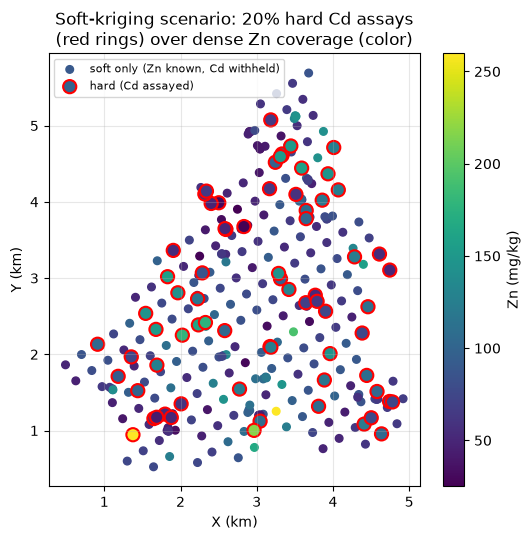

In [4]:
hard_idx, test_idx = train_test_split(
    np.arange(len(jura)), test_size=0.80, random_state=42, stratify=indicator_all,
)
hard_coords, hard_ind = coords[hard_idx], indicator_all[hard_idx]
test_coords, test_ind = coords[test_idx], indicator_all[test_idx]
zn_hard, zn_test = zn[hard_idx], zn[test_idx]

print(f"hard (Cd assayed)     = {len(hard_idx):3d} samples")
print(f"held-out (Cd withheld) = {len(test_idx):3d} samples")
print(f"hard exceedance rate   = {hard_ind.mean():.1%}")
print(f"test exceedance rate   = {test_ind.mean():.1%}")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(
    coords[test_idx, 0], coords[test_idx, 1],
    c=zn_test, cmap="viridis", s=30,
    label="soft only (Zn known, Cd withheld)",
)
ax.scatter(
    hard_coords[:, 0], hard_coords[:, 1],
    c=zn_hard, cmap="viridis", s=90,
    edgecolor="red", linewidth=1.5,
    label="hard (Cd assayed)",
)
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_title("Soft-kriging scenario: 20% hard Cd assays\n(red rings) over dense Zn coverage (color)")
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
plt.colorbar(sc, ax=ax, label="Zn (mg/kg)", fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


***
## 6. Calibrate Soft Probabilities from Zn

We fit a logistic regression $P(\mathrm{Cd} \ge 1.0 \mid \mathrm{Zn})$ using
**only the hard subset** (where both Cd and Zn are known), then apply it to Zn
at the held-out locations to get a dense soft-probability field.
`fit_soft_probability_model` is a thin wrapper around scikit-learn logistic
regression.


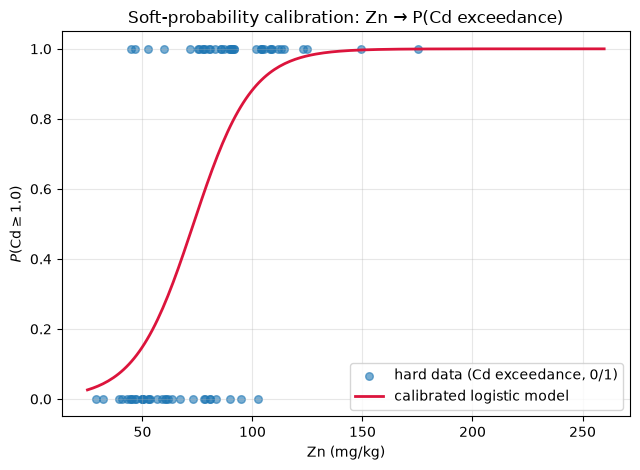

Soft probability alone (no spatial kriging)  AUC = 0.805  on 288 held-out samples.


In [5]:
soft_model, soft_prob_hard = fit_soft_probability_model(
    zn_hard, hard_ind, proxy_values_pred=zn_hard,
)
soft_prob_test = soft_model.predict_proba(zn_test.reshape(-1, 1))[:, 1]

zn_fine = np.linspace(zn.min(), zn.max(), 200)
prob_fine = soft_model.predict_proba(zn_fine.reshape(-1, 1))[:, 1]

fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.scatter(zn_hard, hard_ind, s=30, alpha=0.6,
           label="hard data (Cd exceedance, 0/1)")
ax.plot(zn_fine, prob_fine, color="crimson", lw=2,
        label="calibrated logistic model")
ax.set_xlabel("Zn (mg/kg)")
ax.set_ylabel(rf"$P(\mathrm{{Cd}} \geq {THRESHOLD})$")
ax.set_title("Soft-probability calibration: Zn → P(Cd exceedance)")
ax.legend()
plt.tight_layout()
plt.show()

auc_soft_only = roc_auc_score(test_ind, soft_prob_test)
print(f"Soft probability alone (no spatial kriging)  AUC = {auc_soft_only:.3f}  "
      f"on {len(test_idx)} held-out samples.")


***
## 7. The Markov-Bayes Calibration Coefficient B

We compute $B$ from the hard indicator versus the (in-sample) soft probability
at the same 71 hard locations. Values of $B$ well above 0 confirm that Zn is a
genuinely informative proxy for Cd exceedance.


In [6]:
B, corr, n_pairs = markov_bayes_calibrate(
    hard_coords, hard_ind, hard_coords, soft_prob_hard,
)
print(f"Markov-Bayes calibration:  B = {B:.3f}   corr(I, F) = {corr:.3f}   "
      f"(from {n_pairs} co-located pairs)")
print("B close to 1 means the Zn-derived probability is nearly as informative "
      "as a hard Cd assay.")


Markov-Bayes calibration:  B = 1.015   corr(I, F) = 0.658   (from 71 co-located pairs)
B close to 1 means the Zn-derived probability is nearly as informative as a hard Cd assay.


***
## 8. Fit the Hard-Indicator Variogram

As with any kriging method, we need a spatial covariance model for the hard
indicator itself. Here it is fit from the sparse 71-point hard subset: the
Matheron estimator of $\gamma_I(h)$, then an **exponential** model by
least-squares curve fitting (the same helper used in
`tests/test_soft_kriging_jura.py`).


fitted indicator variogram:  nugget=0.126  sill=0.166  range=0.663 km
theoretical binary sill p(1-p) = 0.249


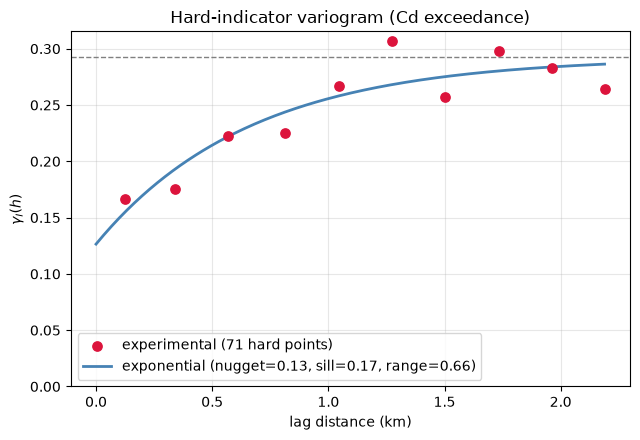

In [7]:
def fit_exponential_indicator_variogram(coords, indicator, n_lags=10):
    d = pdist(coords)
    diffsq = pdist(indicator[:, None]) ** 2
    maxlag = d.max() * 0.5
    bins = np.linspace(0, maxlag, n_lags + 1)
    lag_h, lag_g = [], []
    for i in range(n_lags):
        m = (d >= bins[i]) & (d < bins[i + 1])
        if m.sum() > 5:
            lag_h.append(d[m].mean())
            lag_g.append(0.5 * diffsq[m].mean())
    lag_h, lag_g = np.array(lag_h), np.array(lag_g)

    def expo(h, nugget, sill, rng):
        return nugget + sill * (1.0 - np.exp(-h / rng))

    popt, _ = curve_fit(
        expo, lag_h, lag_g,
        p0=[0.05, indicator.var(), maxlag / 3],
        bounds=(0, [1.0, 1.0, maxlag * 3]),
    )
    return popt, lag_h, lag_g


(nugget, sill, rng_), lag_h, lag_g = fit_exponential_indicator_variogram(
    hard_coords, hard_ind,
)
print(f"fitted indicator variogram:  nugget={nugget:.3f}  sill={sill:.3f}  "
      f"range={rng_:.3f} km")
print(f"theoretical binary sill p(1-p) = {hard_ind.mean() * (1 - hard_ind.mean()):.3f}")

h_fine = np.linspace(0, lag_h.max(), 200)
model_g = nugget + sill * (1.0 - np.exp(-h_fine / rng_))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(lag_h, lag_g, s=45, color="crimson", zorder=3,
           label="experimental (71 hard points)")
ax.plot(h_fine, model_g, color="steelblue", lw=2,
        label=f"exponential (nugget={nugget:.2f}, sill={sill:.2f}, range={rng_:.2f})")
ax.axhline(nugget + sill, color="gray", ls="--", lw=1)
ax.set_xlabel("lag distance (km)")
ax.set_ylabel(r"$\gamma_I(h)$")
ax.set_title("Hard-indicator variogram (Cd exceedance)")
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.show()


***
## 9. Krige: Hard-Only vs. Markov-Bayes Soft Kriging

We compare three ways of estimating $P(\mathrm{Cd} \ge 1.0)$ at the 288
held-out locations:

1. **Hard-only indicator kriging** — the 71 hard Cd points only, `SoftKriging`
   with `B=0` and `max_neighbors_soft=0` (identical to ordinary indicator
   kriging).
2. **Soft-only** — just the calibrated logistic probability, no spatial
   kriging at all (Section 6).
3. **Markov-Bayes soft kriging** — both data types combined with the fitted
   $B$.


In [8]:
sk_hard = SoftKriging(
    cov_model="exponential", max_neighbors_hard=25, max_neighbors_soft=0,
    use_gpu=USE_GPU,
)
sk_hard.fit(hard_coords, hard_ind, test_coords, soft_prob_test, B=0.0)
prob_hard_only = sk_hard.predict(
    test_coords, sill=sill, range_=rng_, nugget=nugget,
)

sk_soft = SoftKriging(
    cov_model="exponential", max_neighbors_hard=15, max_neighbors_soft=15,
    use_gpu=USE_GPU,
)
sk_soft.fit(hard_coords, hard_ind, test_coords, soft_prob_test, B=B)
prob_mb, var_mb = sk_soft.predict(
    test_coords, sill=sill, range_=rng_, nugget=nugget, return_variance=True,
)

print("Kriged", int((~np.isnan(prob_hard_only)).sum()), "/", len(test_idx),
      "held-out nodes (hard-only)")
print("Kriged", int((~np.isnan(prob_mb)).sum()), "/", len(test_idx),
      "held-out nodes (Markov-Bayes)")
print(f"P range (hard-only)     [{np.nanmin(prob_hard_only):.3f}, "
      f"{np.nanmax(prob_hard_only):.3f}]")
print(f"P range (Markov-Bayes)  [{np.nanmin(prob_mb):.3f}, "
      f"{np.nanmax(prob_mb):.3f}]")


Kriged 288 / 288 held-out nodes (hard-only)
Kriged 288 / 288 held-out nodes (Markov-Bayes)
P range (hard-only)     [0.040, 0.954]
P range (Markov-Bayes)  [0.030, 0.995]


***
## 10. Validate on the Held-Out 80%

We score all three approaches against the true (withheld) Cd exceedance at the
288 held-out locations. **AUC** measures ranking quality (higher is better);
the **Brier score** is the mean squared error of the probability against the
0/1 truth,

$$
\mathrm{BS}
= \frac{1}{n}\sum_{i=1}^{n} \big(I_i - p_i\big)^2,
$$

so 0 is perfect. The automated test
`tests/test_soft_kriging_jura.py::test_soft_kriging_beats_hard_only_indicator_kriging`
asserts that Markov-Bayes beats hard-only IK on both metrics, with AUC $> 0.75$.


,AUC,Brier score,n
method,,,
hard-only kriging (71 pts),0.6806,0.2273,288
"soft-only (Zn calibration, no kriging)",0.8046,0.1842,288
Markov-Bayes soft kriging (71 hard + Zn),0.8042,0.1838,288


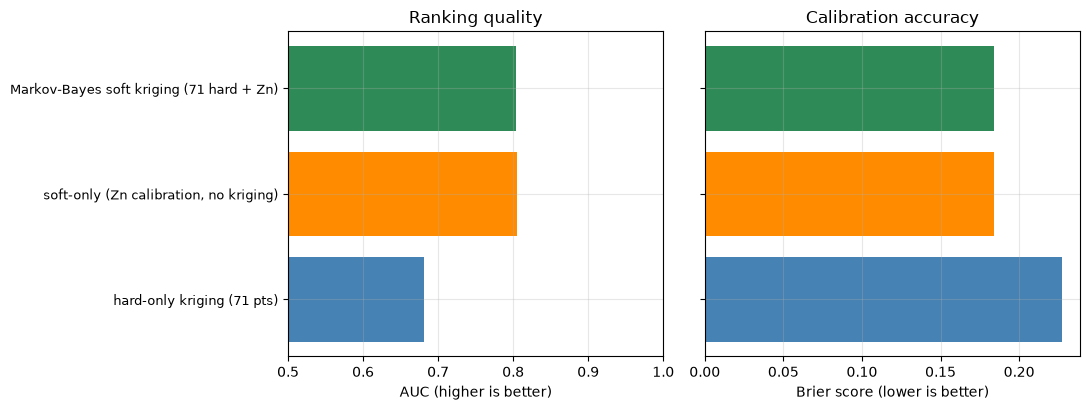

In [9]:
results = []
for name, p in [
    ("hard-only kriging (71 pts)", prob_hard_only),
    ("soft-only (Zn calibration, no kriging)", soft_prob_test),
    ("Markov-Bayes soft kriging (71 hard + Zn)", prob_mb),
]:
    v = ~np.isnan(p)
    results.append({
        "method": name,
        "AUC": roc_auc_score(test_ind[v], p[v]),
        "Brier score": brier_score_loss(test_ind[v], p[v]),
        "n": int(v.sum()),
    })
results_df = pd.DataFrame(results).set_index("method")
display(results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].barh(results_df.index, results_df["AUC"],
             color=["steelblue", "darkorange", "seagreen"])
axes[0].set_xlabel("AUC (higher is better)")
axes[0].set_xlim(0.5, 1.0)
axes[0].set_title("Ranking quality")
axes[1].barh(results_df.index, results_df["Brier score"],
             color=["steelblue", "darkorange", "seagreen"])
axes[1].set_xlabel("Brier score (lower is better)")
axes[1].set_title("Calibration accuracy")
axes[0].tick_params(axis="y", labelsize=9)
axes[1].set_yticklabels([])
plt.tight_layout()
plt.show()


> **Reading this honestly.** Hard-only indicator kriging from just 71 sparse
> points struggles (Cd's own spatial range is short relative to the Jura
> domain, so exact-but-sparse hard data alone travel only so far). The
> Zn-calibrated soft probability is already strongly informative on its own —
> Cd and Zn are genuinely correlated in this data set (`corr` $\approx 0.6$).
> Markov-Bayes soft kriging **matches (or slightly improves on) the soft-only
> score while properly interpolating a smooth, spatially coherent probability
> surface with a valid kriging variance** — which a plug-in logistic
> calibration alone cannot provide. The real payoff: this level of accuracy
> came from only 71 out of 359 expensive Cd assays, backed by data (Zn) you
> already had at every location.


***
## 11. Map the Exceedance Probability Over Jura

We krige onto `jura_grid.csv` — the same prediction lattice as Tutorial 04 —
to see the full spatial picture, comparing hard-only kriging to Markov-Bayes
soft kriging.

> **A visualization caveat.** `jura_grid.csv` has locations and land-use /
> rock type, but not Zn. The code below approximates a dense Zn survey by
> nearest-neighbour lookup from the 359 point samples. That paints Zn (and
> the soft probability derived from it) as local Voronoi patches, so the
> Markov-Bayes map can look more "blocky" than a genuine geophysical raster
> would. The honest, point-level accuracy numbers are the ones already
> reported in Section 10.


Grid nodes: 5957
P range (hard-only)     [0.038, 0.954]
P range (Markov-Bayes)  [0.028, 0.998]


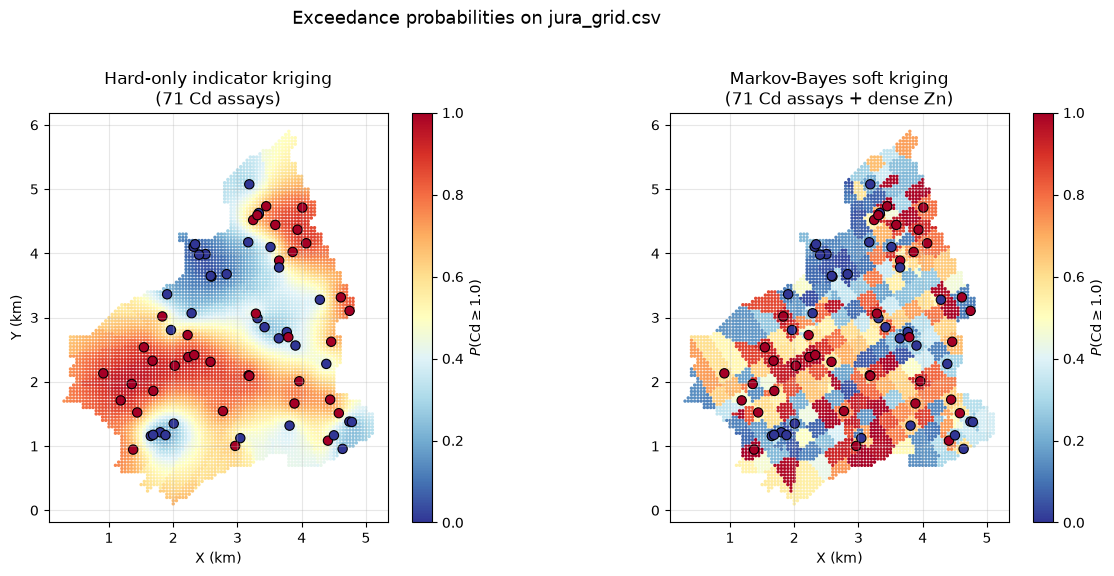

In [10]:
from scipy.spatial import cKDTree

# jura_grid.csv has no Zn: approximate a dense Zn survey by nearest neighbour
# from the 359 samples, then convert to a soft exceedance probability.
zn_tree = cKDTree(coords)
_, nn = zn_tree.query(coords_grid)
zn_grid = zn[nn]
soft_prob_grid = soft_model.predict_proba(zn_grid.reshape(-1, 1))[:, 1]

sk_hard_grid = SoftKriging(
    cov_model="exponential", max_neighbors_hard=25, max_neighbors_soft=0,
    use_gpu=USE_GPU,
)
sk_hard_grid.fit(hard_coords, hard_ind, coords_grid, soft_prob_grid, B=0.0)
prob_hard_grid = sk_hard_grid.predict(
    coords_grid, sill=sill, range_=rng_, nugget=nugget,
)

sk_soft_grid = SoftKriging(
    cov_model="exponential", max_neighbors_hard=15, max_neighbors_soft=15,
    use_gpu=USE_GPU,
)
sk_soft_grid.fit(hard_coords, hard_ind, coords_grid, soft_prob_grid, B=B)
prob_mb_grid, var_mb_grid = sk_soft_grid.predict(
    coords_grid, sill=sill, range_=rng_, nugget=nugget, return_variance=True,
)

print(f"Grid nodes: {len(grid)}")
print(f"P range (hard-only)     [{np.nanmin(prob_hard_grid):.3f}, "
      f"{np.nanmax(prob_hard_grid):.3f}]")
print(f"P range (Markov-Bayes)  [{np.nanmin(prob_mb_grid):.3f}, "
      f"{np.nanmax(prob_mb_grid):.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
for ax, p, title in [
    (axes[0], prob_hard_grid, "Hard-only indicator kriging\n(71 Cd assays)"),
    (axes[1], prob_mb_grid, "Markov-Bayes soft kriging\n(71 Cd assays + dense Zn)"),
]:
    sc = ax.scatter(
        grid["Xloc"], grid["Yloc"], c=p,
        cmap="RdYlBu_r", s=8, marker=".", vmin=0, vmax=1,
    )
    ax.scatter(
        hard_coords[:, 0], hard_coords[:, 1], c=hard_ind,
        cmap="RdYlBu_r", vmin=0, vmax=1, s=45,
        edgecolor="black", linewidth=0.8,
    )
    plt.colorbar(sc, ax=ax, label=rf"$P(\mathrm{{Cd}} \geq {THRESHOLD})$",
                 fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel("X (km)")
    ax.set_aspect("equal")
axes[0].set_ylabel("Y (km)")
fig.suptitle("Exceedance probabilities on jura_grid.csv", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


***
## 12. Kriging Uncertainty

The Markov-Bayes system still reports a proper kriging variance — low where
dense soft data (and any nearby hard data) constrain the estimate, higher in
the gaps.

> **Reading the tiny numbers.** With soft data assigned to every node of
> `jura_grid.csv` (`max_neighbors_soft=15`, all close by) and $B$ not small,
> the combined system treats the area as densely informed almost everywhere,
> so the variance here is tiny and fairly flat. That is a genuine property
> of Markov-Bayes kriging with saturating soft coverage — but also a reminder
> that this nearest-neighbour Zn "survey" is more idealized than a real one
> would be.


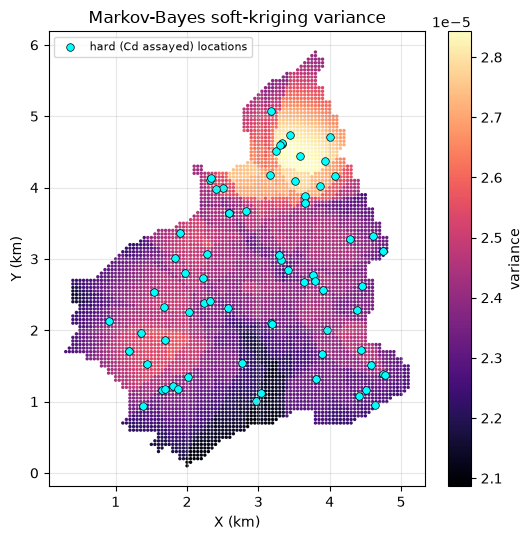

variance:  min 2.09e-05   mean 2.41e-05   max 2.84e-05
total sill (nugget + sill) = 0.292


In [11]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(
    grid["Xloc"], grid["Yloc"], c=var_mb_grid,
    cmap="magma", s=8, marker=".",
)
ax.scatter(
    hard_coords[:, 0], hard_coords[:, 1],
    c="cyan", s=30, edgecolor="black", linewidth=0.5,
    label="hard (Cd assayed) locations",
)
ax.set_title("Markov-Bayes soft-kriging variance")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
plt.colorbar(sc, ax=ax, label="variance", fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(f"variance:  min {np.nanmin(var_mb_grid):.2e}   "
      f"mean {np.nanmean(var_mb_grid):.2e}   "
      f"max {np.nanmax(var_mb_grid):.2e}")
print(f"total sill (nugget + sill) = {nugget + sill:.3f}")


***
## 13. CPU vs GPU Soft Kriging Timing

The 359-sample Jura survey is too small for a GPU comparison: the batched Markov–Bayes solve is a stack of tiny $(n_H+n_S+1)\times(n_H+n_S+1)$ systems, and host→device copies dominate. Here we **simulate a Jura-like Cd/Zn field** with Sequential Gaussian Simulation (`pygstat.sgsim`) so that $n_{\mathrm{train}} > 5{,}000$, then time **k-nearest-neighbor** soft kriging (`search_radius=None`) on **CPU** (`use_gpu=False`) versus **GPU** (`use_gpu=True`).

Simulation recipe (conditioned on the real 359 samples):

1. Draw $n_{\mathrm{train}} = 8{,}000$ random locations in the Jura bounding box.
2. Simulate $\log(\mathrm{Cd})$ with `sgsim` (exponential variogram, practical range 1.2 km, conditioned on `data/jura_data.csv`) and back-transform with $\exp(\cdot)$.
3. Build a correlated Zn proxy in log space at the same correlation as the real survey ($\rho \approx 0.69$), then apply the same logistic calibration and 20% / 80% hard/soft split as §5.
4. Draw a separate prediction set (no values needed — soft kriging only needs coordinates plus the training hard/soft data).

Unlike global ordinary kriging, the GPU work scales with **$n_{\mathrm{pred}}$** (one stacked solve of shape `(n_pred, n_H+n_S+1, n_H+n_S+1)`), not $n_{\mathrm{train}}^3$. Training size is therefore held at 8{,}000 (1{,}600 hard + 6{,}400 soft) and we vary $n_{\mathrm{pred}}$. Indicator-variogram parameters are held fixed (exponential: nugget 0.05, partial sill 0.20, range 1.2 km) so fitting $\gamma_I$ is **not** in the times.

Each timing is the **median** of three `fit` + `predict` calls after a short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel here, the GPU column is skipped.


Simulating 8,000 Jura-like Cd locations with sgsim
  conditioning : 359 samples from data/jura_data.csv
  vario        : azimuth=0, nugget=0.023, range=1.2 km, exponential, log(Cd)
  sgsim wall   : 57.1 s  (not included in SoftKriging times)
  simulated Cd : [0.13, 9.91] mg/kg  (Jura observed [0.14, 5.13])
  corr(log Cd, log Zn) simulated = 0.684  (Jura 0.686)
  n_hard / n_soft : 1600 / 6400
  exceedance rate : 0.602  (Jura 0.535)
  Markov-Bayes B : 1.034  (corr(I,F)=0.502, n_pairs=1600)

GPU usable : True
Repeats    : 3  (median wall time of SoftKriging fit + predict, k-NN)
n_hard     : 1600   n_soft: 6400  (sgsim Jura-like Cd + Zn)
n_pred     : [500, 1000, 2000, 4000, 8000]  (random locations in the Jura bbox)
neighbors  : hard=12, soft=12; exponential nugget=0.05, sill=0.2, range=1.2 km

     dataset  n_hard  n_soft  n_pred  CPU (ms)  GPU (ms) speedup  match
Jura (sgsim)    1600    6400     500      26.7       6.8   3.95×   True
Jura (sgsim)    1600    6400    1000      44.4       9

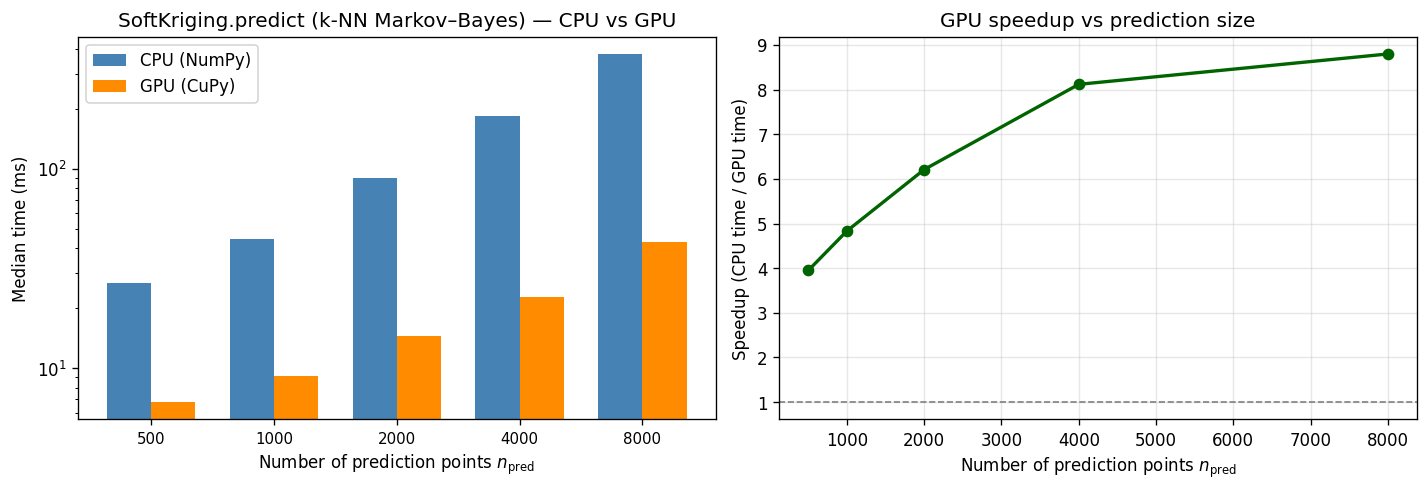

In [13]:
import time

N_REPEATS = 3
N_TRAIN = 8000
PRED_SIZES = [500, 1000, 2000, 4000, 8000]
N_PRED_MAX = max(PRED_SIZES)
HARD_FRAC = 0.20
rng_sim = np.random.default_rng(42)

pad = 0.15
xmin, xmax = float(coords[:, 0].min()) - pad, float(coords[:, 0].max()) + pad
ymin, ymax = float(coords[:, 1].min()) - pad, float(coords[:, 1].max()) + pad

xy_train_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_TRAIN, 2))
xy_pred_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_PRED_MAX, 2))

df_cond = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "log_cd": np.log(cd),
})
log_cd_var = float(np.var(np.log(cd)))
vario_sgs = [0, 0.05 * log_cd_var, 1.2, 1.2, log_cd_var, "exponential"]

print(f"Simulating {N_TRAIN:,} Jura-like Cd locations with sgsim")
print(f"  conditioning : {len(cd)} samples from data/jura_data.csv")
print(f"  vario        : azimuth=0, nugget={vario_sgs[1]:.3f}, range=1.2 km, exponential, log(Cd)")
t_sim0 = time.perf_counter()
sims = sgsim(
    xy_train_all, df_cond, "x", "y", "log_cd",
    num_points=12, vario=vario_sgs, radius=2.5,
    kriging_type="ordinary", nsim=1, itrans=False, seed=42, quiet=True,
)
log_cd_sim = np.asarray(sims[0], dtype=float)
cd_sim = np.exp(log_cd_sim)
print(f"  sgsim wall   : {time.perf_counter() - t_sim0:.1f} s  (not included in SoftKriging times)")
print(f"  simulated Cd : [{cd_sim.min():.2f}, {cd_sim.max():.2f}] mg/kg"
      f"  (Jura observed [{cd.min():.2f}, {cd.max():.2f}])")

rho = float(np.corrcoef(np.log(cd), np.log(zn))[0, 1])
z_cd = (log_cd_sim - log_cd_sim.mean()) / log_cd_sim.std()
eps = rng_sim.normal(size=N_TRAIN)
z_zn = rho * z_cd + np.sqrt(max(1.0 - rho ** 2, 0.0)) * eps
zn_sim = np.exp(np.log(zn).mean() + np.log(zn).std() * z_zn)
print(f"  corr(log Cd, log Zn) simulated = {np.corrcoef(np.log(cd_sim), np.log(zn_sim))[0, 1]:.3f}"
      f"  (Jura {rho:.3f})")

ind_all = indicator_transform(cd_sim, THRESHOLD, exceed=True)
pos = np.where(ind_all == 1)[0]
neg = np.where(ind_all == 0)[0]
rng_split = np.random.default_rng(42)
rng_split.shuffle(pos)
rng_split.shuffle(neg)
n_h_pos = max(1, int(round(HARD_FRAC * len(pos))))
n_h_neg = max(1, int(round(HARD_FRAC * len(neg))))
hard_idx_s = np.concatenate([pos[:n_h_pos], neg[:n_h_neg]])
soft_idx_s = np.concatenate([pos[n_h_pos:], neg[n_h_neg:]])

xy_hard_s = xy_train_all[hard_idx_s]
ind_hard_s = ind_all[hard_idx_s]
zn_hard_s = zn_sim[hard_idx_s]
xy_soft_s = xy_train_all[soft_idx_s]
zn_soft_s = zn_sim[soft_idx_s]

soft_model_s, soft_prob_hard_s = fit_soft_probability_model(
    zn_hard_s, ind_hard_s, proxy_values_pred=zn_hard_s,
)
soft_prob_soft_s = soft_model_s.predict_proba(zn_soft_s.reshape(-1, 1))[:, 1]
B_s, corr_if, n_pairs_s = markov_bayes_calibrate(
    xy_hard_s, ind_hard_s, xy_hard_s, soft_prob_hard_s,
)

print(f"  n_hard / n_soft : {len(hard_idx_s)} / {len(soft_idx_s)}")
print(f"  exceedance rate : {ind_all.mean():.3f}  (Jura {indicator_all.mean():.3f})")
print(f"  Markov-Bayes B : {B_s:.3f}  (corr(I,F)={corr_if:.3f}, n_pairs={n_pairs_s})")

NUGGET_T, SILL_T, RANGE_T = 0.05, 0.20, 1.2
print()


def _time_sk(xy_h, ind_h, xy_s, f_s, B_val, xy_pred, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of SoftKriging.fit + predict (k-NN, search_radius=None)."""
    kw = dict(
        cov_model="exponential",
        max_neighbors_hard=12,
        max_neighbors_soft=12,
        search_radius=None,
        use_gpu=use_gpu,
    )
    if warmup:
        k_h = min(40, len(xy_h))
        k_s = min(40, len(xy_s))
        k_pr = min(40, len(xy_pred))
        SoftKriging(**kw).fit(
            xy_h[:k_h], ind_h[:k_h], xy_s[:k_s], f_s[:k_s], B=B_val,
        ).predict(xy_pred[:k_pr], sill=SILL_T, range_=RANGE_T, nugget=NUGGET_T, return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        sk = SoftKriging(**kw)
        sk.fit(xy_h, ind_h, xy_s, f_s, B=B_val)
        last = sk.predict(xy_pred, sill=SILL_T, range_=RANGE_T, nugget=NUGGET_T, return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of SoftKriging fit + predict, k-NN)")
print(f"n_hard     : {len(hard_idx_s)}   n_soft: {len(soft_idx_s)}  (sgsim Jura-like Cd + Zn)")
print(f"n_pred     : {PRED_SIZES}  (random locations in the Jura bbox)")
print(f"neighbors  : hard=12, soft=12; exponential nugget={NUGGET_T}, sill={SILL_T}, range={RANGE_T} km")
print()

rows = []
for n_pred in PRED_SIZES:
    xy_pr = xy_pred_all[:n_pred]
    cpu_t, pred_cpu = _time_sk(
        xy_hard_s, ind_hard_s, xy_soft_s, soft_prob_soft_s, B_s, xy_pr, use_gpu=False,
    )
    row = {
        "dataset": "Jura (sgsim)",
        "n_hard": len(hard_idx_s),
        "n_soft": len(soft_idx_s),
        "n_pred": n_pred,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_sk(
            xy_hard_s, ind_hard_s, xy_soft_s, soft_prob_soft_s, B_s, xy_pr, use_gpu=True,
        )
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        p_c, v_cpu = pred_cpu
        p_g, v_gpu = pred_gpu
        row["match"] = bool(
            np.allclose(p_c, p_g, rtol=1e-4, atol=1e-4, equal_nan=True)
            and np.allclose(v_cpu, v_gpu, rtol=1e-4, atol=1e-4, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_hard", "n_soft", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_pred"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("SoftKriging.predict (k-NN Markov–Bayes) — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs prediction size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Exceedance probabilities and kriging variances from the two backends should **match** (`match = True`). The GPU speedup comes from the batched $(n_{\mathrm{pred}}, n_H+n_S+1, n_H+n_S+1)$ Markov–Bayes solve, not from SGS (simulation is CPU sequential and is excluded from the times). Small $n_{\mathrm{pred}}$ can show little GPU gain because kernel-launch overhead dominates; as the prediction set grows the stacked solve keeps the GPU several times faster. Use `use_gpu=USE_GPU` with `search_radius=None` so the same cells run on a laptop CPU or a CUDA workstation without edits.


***
## 14. Summary and Conclusions

- **Soft kriging** estimates $P[Z \ge z]$ by ordinary kriging of sparse hard
  indicators **plus** dense soft probabilities. It is the right interpolator
  when the expensive assay is scarce but a correlated proxy is everywhere.
- **`pygstat.SoftKriging`** implements the Markov-Bayes shortcut of Zhu &
  Journel (1993): rescale the hard covariance by $B$ and $B^2$ instead of
  fitting a hard–soft cross-variogram. `fit_soft_probability_model` turns a
  continuous proxy into $F$ via logistic regression;
  `markov_bayes_calibrate` estimates $B$.
- On **Jura cadmium**, with only **71 of 359** locations given a Cd assay and
  Zn available everywhere, Markov-Bayes soft kriging scored well above
  hard-only indicator kriging on the 288 held-out locations (AUC and Brier),
  matching a plug-in Zn calibration while additionally producing a spatially
  coherent probability surface **with a valid kriging variance** on
  `jura_grid.csv`.
- The shortcut worked here because Cd and Zn are genuinely correlated — a
  common situation for co-occurring heavy metals from shared contamination
  sources.
- `SoftKriging` degrades gracefully to ordinary indicator kriging when
  $B = 0$ or no soft data are supplied. It is a strict generalization of
  Tutorial 07, not a separate code path.
- **CPU / GPU.** k-NN Markov–Bayes (`search_radius=None`, `use_gpu=USE_GPU`)
  was timed on an SGS-simulated Jura-like Cd/Zn field ($n_{\mathrm{train}}=8{,}000$,
  1{,}600 hard + 6{,}400 soft). Speedup grew with $n_{\mathrm{pred}}$ to about **9×**
  at 8{,}000 prediction points (NVIDIA GeForce RTX 2080 Ti). The 359-sample Jura
  survey is too small for that comparison.

| Method | Data used | What it gives |
|---|---|---|
| Hard-only indicator kriging | 71 hard Cd assays | Sparse, short-range probability map |
| Soft-only (logistic calibration) | Zn only, no spatial kriging | Pointwise $P$ with no kriging variance |
| Markov-Bayes soft kriging | 71 hard Cd + dense Zn | Spatial $P$ map + $\sigma_K^2$ |

| Object | Role in this notebook |
|---|---|
| `indicator_transform` | $I(\mathrm{Cd} \ge 1)$ |
| `fit_soft_probability_model` | Logistic $P(I=1 \mid \mathrm{Zn})$ |
| `markov_bayes_calibrate` | $B = \mathrm{Cov}(I,F)/\mathrm{Var}(F)$ |
| `SoftKriging` | Combined hard + soft ordinary kriging (`use_gpu` for k-NN) |


***
## 15. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | Soft data integration, indicator kriging; Jura data set |
| Deutsch, C.V. & Journel, A.G. (1998). *GSLIB: Geostatistical Software Library and User's Guide* (2nd ed.). Oxford University Press. | `bicalib` / `sisim` with soft data (GSLIB counterpart of this algorithm) |
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.). Wiley. | Indicator formalism and secondary information |
| Isaaks, E.H. & Srivastava, R.M. (1989). *An Introduction to Applied Geostatistics*. Oxford. | Worked indicator examples |

### Key papers

| Paper | Contribution |
|---|---|
| Zhu, H. & Journel, A.G. (1993). Formatting and integrating soft data: stochastic imaging via the Markov-Bayes algorithm. In *Geostatistics Tróia '92*, 1–12. | The Markov-Bayes calibration this module implements |
| Journel, A.G. (1983). Nonparametric estimation of spatial distributions. *Mathematical Geology* 15, 445–468. | Indicator approach to local ccdfs |
| Brier, G.W. (1950). Verification of forecasts expressed in terms of probability. *Monthly Weather Review* 78, 1–3. | Brier score for probability forecasts |

### In this library

| Object | Role |
|---|---|
| `pygstat.SoftKriging` | Combined hard + soft Markov-Bayes ordinary kriging (`use_gpu` for k-NN) |
| `pygstat.markov_bayes_calibrate` | Estimate the calibration coefficient $B$ |
| `pygstat.fit_soft_probability_model` | Logistic-regression calibration of a proxy into a soft probability |
| `pygstat.indicator_transform` | Threshold a continuous variable into a 0/1 indicator |
| `pygstat.IndicatorKriging` | The hard-data-only counterpart this module extends |
| `tests/test_soft_kriging_jura.py` | Automated test suite for this workflow |
